# Supplier Intelligence Copilot — AI Product Analytics

This notebook evaluates the Supplier Intelligence Copilot from a product perspective.

Since the project is a portfolio prototype rather than a live production deployment, synthetic copilot telemetry is generated to simulate user interactions.

### Product Questions

- Are users adopting the copilot?
- Which query types are used most frequently?
- How often are answers accepted?
- Which AI route performs best: SQL, RAG or Hybrid?
- How frequently do users regenerate answers?
- What is the latency of different AI workflows?
- Does a new prompt version improve answer quality?
- Should the new prompt be rolled out?

Imports + Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Supplier-Intelligence-Copilot')

Generate Synthetic Copilot Telemetry

In a real production application, these events would be generated automatically whenever someone uses the copilot.

We'll simulate

2,500 queries

~100 users

SQL questions

RAG questions

Hybrid questions

Prompt V1

Prompt V2

In [3]:
n_events = 2500

users = [
    f"USER_{i:03d}"
    for i in range(1, 101)
]

routes = np.random.choice(
    [
        "SQL",
        "RAG",
        "HYBRID"
    ],
    size=n_events,
    p=[
        0.35,
        0.30,
        0.35
    ]
)

prompt_versions = np.random.choice(
    [
        "V1",
        "V2"
    ],
    size=n_events,
    p=[
        0.5,
        0.5
    ]
)

Create timestamps

In [4]:
start_date = pd.Timestamp(
    "2026-05-01"
)

timestamps = (
    start_date
    + pd.to_timedelta(
        np.random.randint(
            0,
            60 * 24 * 60,
            size=n_events
        ),
        unit="m"
    )
)

Now generate product behaviour.

We'll deliberately make Prompt V2 slightly better so we have something meaningful to test

In [5]:
records = []

for i in range(n_events):

    route = routes[i]
    prompt_version = prompt_versions[i]

    # -------------------------
    # Base performance by route
    # -------------------------

    if route == "SQL":

        base_acceptance = 0.76
        base_latency = 700
        query_type = "KPI Lookup"

    elif route == "RAG":

        base_acceptance = 0.68
        base_latency = 1700
        query_type = "Issue Investigation"

    else:

        base_acceptance = 0.65
        base_latency = 2300
        query_type = "Supplier Diagnosis"

    # Prompt V2 performs slightly better
    if prompt_version == "V2":
        acceptance_probability = (
            base_acceptance + 0.06
        )

        latency_penalty = 120

    else:
        acceptance_probability = (
            base_acceptance
        )

        latency_penalty = 0

    answer_accepted = np.random.rand() < (
        acceptance_probability
    )

    thumbs_up_probability = (
        0.80
        if answer_accepted
        else 0.20
    )

    thumbs_up = (
        np.random.rand()
        < thumbs_up_probability
    )

    regeneration_probability = (
        0.08
        if answer_accepted
        else 0.38
    )

    regenerated = (
        np.random.rand()
        < regeneration_probability
    )

    latency_ms = max(
        300,
        np.random.normal(
            base_latency
            + latency_penalty,
            250
        )
    )

    records.append({
        "event_id":
            f"EVT_{i + 1:05d}",

        "timestamp":
            timestamps[i],

        "user_id":
            np.random.choice(users),

        "route":
            route,

        "query_type":
            query_type,

        "prompt_version":
            prompt_version,

        "answer_accepted":
            int(answer_accepted),

        "thumbs_up":
            int(thumbs_up),

        "regenerated":
            int(regenerated),

        "latency_ms":
            round(latency_ms, 0)
    })


events_df = pd.DataFrame(
    records
)

events_df.head()

,event_id,timestamp,user_id,route,query_type,prompt_version,answer_accepted,thumbs_up,regenerated,latency_ms
0,EVT_00001,2026-06-01 02:18:00,USER_002,SQL,KPI Lookup,V2,1,0,0,555.0
1,EVT_00002,2026-05-06 14:24:00,USER_021,RAG,Issue Investigation,V1,1,1,0,2271.0
2,EVT_00003,2026-05-24 13:27:00,USER_056,HYBRID,Supplier Diagnosis,V1,1,1,1,2758.0
3,EVT_00004,2026-05-30 21:16:00,USER_030,SQL,KPI Lookup,V1,0,0,0,957.0
4,EVT_00005,2026-06-10 19:11:00,USER_031,SQL,KPI Lookup,V2,1,1,0,700.0


In [6]:
events_df.shape

(2500, 10)

Save telemetry

In [7]:
EVENTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "copilot_events.csv"
)

events_df.to_csv(
    EVENTS_PATH,
    index=False
)

EVENTS_PATH

WindowsPath('d:/Supplier-Intelligence-Copilot/data/copilot_events.csv')

## AI Product KPI Framework

The copilot is evaluated across four dimensions.

### Adoption
- Active users
- Total queries
- Queries per user

### Answer Quality
- Answer acceptance rate
- Positive feedback rate
- Regeneration rate

### AI System Performance
- Median latency
- P95 latency

### Experimentation
- Prompt V1 vs Prompt V2
- Acceptance uplift
- Regeneration reduction
- Latency trade-off

In [8]:
total_queries = len(
    events_df
)

active_users = (
    events_df["user_id"]
    .nunique()
)

queries_per_user = (
    total_queries
    / active_users
)

acceptance_rate = (
    events_df[
        "answer_accepted"
    ].mean()
)

positive_feedback_rate = (
    events_df[
        "thumbs_up"
    ].mean()
)

regeneration_rate = (
    events_df[
        "regenerated"
    ].mean()
)

median_latency = (
    events_df[
        "latency_ms"
    ].median()
)

p95_latency = (
    events_df[
        "latency_ms"
    ].quantile(0.95)
)

Put them in one table

In [9]:
product_kpis = pd.DataFrame({
    "Metric": [
        "Total Queries",
        "Active Users",
        "Queries per User",
        "Answer Acceptance Rate",
        "Positive Feedback Rate",
        "Regeneration Rate",
        "Median Latency (ms)",
        "P95 Latency (ms)"
    ],

    "Value": [
        total_queries,
        active_users,
        round(
            queries_per_user,
            2
        ),
        round(
            acceptance_rate * 100,
            2
        ),
        round(
            positive_feedback_rate * 100,
            2
        ),
        round(
            regeneration_rate * 100,
            2
        ),
        round(
            median_latency,
            0
        ),
        round(
            p95_latency,
            0
        )
    ]
})

product_kpis

,Metric,Value
0,Total Queries,2500.00
1,Active Users,100.00
2,Queries per User,25.00
3,Answer Acceptance Rate,73.28
4,Positive Feedback Rate,64.28
5,Regeneration Rate,15.28
6,Median Latency (ms),1712.00
7,P95 Latency (ms),2611.00


Which Copilot Route Performs Best?

In [10]:
route_performance = (
    events_df
    .groupby("route")
    .agg(
        queries=(
            "event_id",
            "count"
        ),

        acceptance_rate=(
            "answer_accepted",
            "mean"
        ),

        thumbs_up_rate=(
            "thumbs_up",
            "mean"
        ),

        regeneration_rate=(
            "regenerated",
            "mean"
        ),

        median_latency=(
            "latency_ms",
            "median"
        )
    )
    .reset_index()
)

route_performance[
    [
        "acceptance_rate",
        "thumbs_up_rate",
        "regeneration_rate"
    ]
] *= 100

route_performance.round(2)

,route,queries,acceptance_rate,thumbs_up_rate,regeneration_rate,median_latency
0,HYBRID,853,69.28,61.08,16.06,2355.0
1,RAG,736,70.38,62.77,16.44,1741.0
2,SQL,911,79.36,68.50,13.61,765.0


Adoption Over Time

In [11]:
events_df[
    "date"
] = pd.to_datetime(
    events_df["timestamp"]
).dt.date

Daily queries

In [12]:
daily_usage = (
    events_df
    .groupby("date")
    .agg(
        queries=(
            "event_id",
            "count"
        ),

        active_users=(
            "user_id",
            "nunique"
        )
    )
    .reset_index()
)

daily_usage.head()

,date,queries,active_users
0,2026-05-01,34,32
1,2026-05-02,41,31
2,2026-05-03,43,36
3,2026-05-04,32,30
4,2026-05-05,45,37


Plot

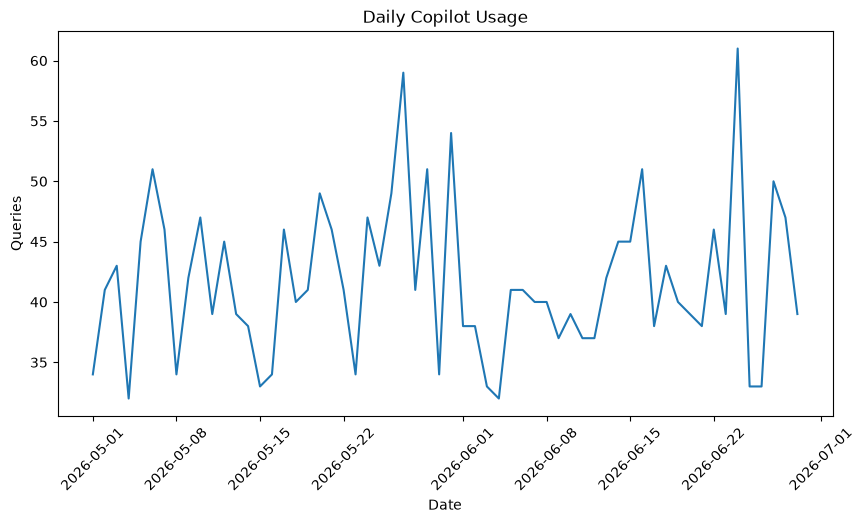

In [13]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    daily_usage["date"],
    daily_usage["queries"]
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Queries"
)

plt.title(
    "Daily Copilot Usage"
)

plt.xticks(
    rotation=45
)

plt.show()

A/B Test — Prompt V1 vs Prompt V2

Control

Prompt V1

vs

Treatment

Prompt V2

Hypothesis:

Prompt V2 improves answer acceptance without causing an unacceptable latency increase.

In [14]:
experiment_results = (
    events_df
    .groupby(
        "prompt_version"
    )
    .agg(
        queries=(
            "event_id",
            "count"
        ),

        acceptance_rate=(
            "answer_accepted",
            "mean"
        ),

        positive_feedback_rate=(
            "thumbs_up",
            "mean"
        ),

        regeneration_rate=(
            "regenerated",
            "mean"
        ),

        median_latency=(
            "latency_ms",
            "median"
        )
    )
    .reset_index()
)

experiment_results[
    [
        "acceptance_rate",
        "positive_feedback_rate",
        "regeneration_rate"
    ]
] *= 100

experiment_results.round(2)

,prompt_version,queries,acceptance_rate,positive_feedback_rate,regeneration_rate,median_latency
0,V1,1270,68.9,61.73,16.22,1706.5
1,V2,1230,77.8,66.91,14.31,1721.5


Calculate uplift

In [15]:
v1 = (
    experiment_results
    .query(
        "prompt_version == 'V1'"
    )
    .iloc[0]
)

v2 = (
    experiment_results
    .query(
        "prompt_version == 'V2'"
    )
    .iloc[0]
)

In [16]:
acceptance_uplift = (
    v2["acceptance_rate"]
    - v1["acceptance_rate"]
)

regeneration_change = (
    v2["regeneration_rate"]
    - v1["regeneration_rate"]
)

latency_change = (
    v2["median_latency"]
    - v1["median_latency"]
)

print(
    "Acceptance uplift:",
    round(
        acceptance_uplift,
        2
    ),
    "percentage points"
)

print(
    "Regeneration change:",
    round(
        regeneration_change,
        2
    ),
    "percentage points"
)

print(
    "Median latency change:",
    round(
        latency_change,
        0
    ),
    "ms"
)

Acceptance uplift: 8.91 percentage points
Regeneration change: -1.91 percentage points
Median latency change: 15.0 ms


Is the Acceptance Improvement Statistically Significant?

Let's perform a two-proportion z-test without adding another library

In [17]:
from math import sqrt
from statistics import NormalDist

def two_proportion_z_test(
    success_a,
    n_a,
    success_b,
    n_b
):

    p_a = (
        success_a
        / n_a
    )

    p_b = (
        success_b
        / n_b
    )

    pooled_p = (
        success_a
        + success_b
    ) / (
        n_a
        + n_b
    )

    standard_error = sqrt(
        pooled_p
        * (1 - pooled_p)
        * (
            1 / n_a
            + 1 / n_b
        )
    )

    z_score = (
        p_b - p_a
    ) / standard_error

    p_value = (
        2
        * (
            1
            - NormalDist()
            .cdf(
                abs(z_score)
            )
        )
    )

    return (
        z_score,
        p_value
    )

Get experiment samples

In [18]:
v1_events = events_df[
    events_df[
        "prompt_version"
    ] == "V1"
]

v2_events = events_df[
    events_df[
        "prompt_version"
    ] == "V2"
]

Run the test

In [19]:
z_score, p_value = (
    two_proportion_z_test(

        success_a=
            v1_events[
                "answer_accepted"
            ].sum(),

        n_a=
            len(v1_events),

        success_b=
            v2_events[
                "answer_accepted"
            ].sum(),

        n_b=
            len(v2_events)
    )
)

In [20]:
print(
    "Z-score:",
    round(
        z_score,
        3
    )
)

print(
    "P-value:",
    round(
        p_value,
        4
    )
)

Z-score: 5.032
P-value: 0.0


In [21]:
if p_value < 0.05:

    print(
        "The difference is statistically significant."
    )

else:

    print(
        "There is insufficient evidence of "
        "a statistically significant difference."
    )

The difference is statistically significant.


Final Product Recommendation

## Product Recommendation

The AI Product Analytics framework evaluates the Supplier Intelligence Copilot across adoption, answer quality, engagement and system performance.

The analysis highlights an important product trade-off:

- SQL queries are fastest and achieve strong answer acceptance.
- RAG enables qualitative supplier investigation but introduces additional latency.
- Hybrid SQL + RAG questions provide richer supplier diagnosis but are the most computationally expensive workflow.

### Prompt Experiment

Prompt V2 was evaluated against Prompt V1 using answer acceptance as the primary success metric.

The experiment also monitored:

- positive feedback
- regeneration rate
- latency

A rollout decision should therefore consider both answer-quality uplift and the additional inference latency introduced by the treatment.

### Product Strategy

Future optimization should prioritize:

1. improving Hybrid query answer quality
2. reducing RAG and Hybrid retrieval/inference latency
3. monitoring regeneration as an indicator of poor answer usefulness
4. continuously experimenting with prompts and retrieval configurations
5. instrumenting production usage to replace synthetic telemetry with real user behavior